# Quebras estruturais e eventos

**Objetivo:** verificar se a serie muda de regime ao longo do tempo, comparar periodos relevantes e detectar possiveis pontos de ruptura.

Em series de saude isso e especialmente importante porque nem sempre faz sentido assumir que o processo gerador dos dados foi estavel do inicio ao fim. Mudancas de comportamento podem refletir:
- pandemia e periodos pos-pandemicos;
- ondas epidemiologicas;
- alteracoes de notificacao ou acesso ao sistema;
- mudancas abruptas de nivel medio e de variabilidade.

Nesta etapa vamos combinar:
- comparacao entre **pre-COVID**, **COVID agudo** e **pos-COVID**;
- deteccao de **ondas** com base na media movel de 30 dias;
- inspeccao de mudancas abruptas de **nivel** e **variancia**;
- deteccao automatica de **changepoints** em escala mensal.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import rankdata

In [2]:
def classificar_periodo_covid(data):
    if data < pd.Timestamp("2020-01-01"):
        return "Pre-COVID"
    if data < pd.Timestamp("2022-01-01"):
        return "COVID agudo"
    return "Pos-COVID"


def pettitt_test(serie):
    """Teste de Pettitt para detectar uma quebra principal em uma serie ordenada."""
    serie = serie.dropna()
    x = serie.to_numpy(dtype=float)
    n = len(x)
    ranks = rankdata(x)
    u_t = 2 * np.cumsum(ranks) - np.arange(1, n + 1) * (n + 1)
    k = np.abs(u_t).max()
    t = int(np.abs(u_t).argmax())
    p = float(min(1.0, 2 * np.exp((-6 * (k**2)) / (n**3 + n**2))))
    return {
        "data_changepoint": serie.index[t],
        "estatistica_k": float(k),
        "p_valor_aprox": p,
        "n_observacoes": int(n),
    }


def detectar_candidatos_por_score(serie_score, distance=45, quantil_prom=0.90, top_n=8):
    """Detecta datas candidatas de ruptura a partir de um escore de mudanca."""
    serie_score = serie_score.dropna().copy()
    if serie_score.empty:
        return pd.DataFrame(columns=["data", "score", "prominencia"])

    prominencia_ref = float(serie_score.quantile(quantil_prom))
    if prominencia_ref <= 0:
        prominencia_ref = float(max(serie_score.std(), 1e-6))

    peaks, props = find_peaks(serie_score.to_numpy(), distance=distance, prominence=prominencia_ref)

    if len(peaks) == 0:
        fallback = serie_score.nlargest(top_n)
        return pd.DataFrame({"data": fallback.index, "score": fallback.values, "prominencia": np.nan})

    return pd.DataFrame(
        {
            "data": serie_score.index[peaks],
            "score": serie_score.iloc[peaks].to_numpy(),
            "prominencia": props["prominences"],
        }
    ).sort_values("score", ascending=False).head(top_n)


def normalizar_z(serie):
    serie = serie.astype(float)
    desvio = serie.std()
    if pd.isna(desvio) or desvio == 0:
        return pd.Series(np.zeros(len(serie)), index=serie.index)
    return (serie - serie.mean()) / desvio

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [ ]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.csv"

df_internacoes = pd.read_csv(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

## Quebras estruturais e eventos

In [ ]:
serie_eventos = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_eventos = int(serie_eventos.isna().sum())
if faltantes_eventos > 0:
    print(f"Foram encontrados {faltantes_eventos} dias faltantes. A serie sera interpolada para a analise de quebras estruturais.")
    serie_eventos = serie_eventos.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a analise de quebras estruturais.")

df_eventos = pd.DataFrame(index=serie_eventos.index)
df_eventos["num_internacoes"] = serie_eventos
df_eventos["ano"] = df_eventos.index.year
df_eventos["periodo_covid"] = pd.Categorical(
    df_eventos.index.to_series().apply(classificar_periodo_covid),
    categories=["Pre-COVID", "COVID agudo", "Pos-COVID"],
    ordered=True,
)
df_eventos["pre_pos_covid"] = np.where(df_eventos.index < pd.Timestamp("2020-03-01"), "Pre-COVID", "Pos-COVID")
df_eventos["media_movel_7d"] = df_eventos["num_internacoes"].rolling(window=7, min_periods=1).mean()
df_eventos["media_movel_30d"] = df_eventos["num_internacoes"].rolling(window=30, min_periods=1).mean()
df_eventos["desvio_movel_30d"] = df_eventos["num_internacoes"].rolling(window=30, min_periods=10).std()

display(df_eventos.head(10))

Nenhum dia faltante foi encontrado para a analise de quebras estruturais.


,num_internacoes,ano,periodo_covid,pre_pos_covid,media_movel_7d,media_movel_30d,desvio_movel_30d
data_dia,,,,,,,
2012-01-01,234,2012,Pre-COVID,Pre-COVID,234.000000,234.000000,NaN
2012-01-02,336,2012,Pre-COVID,Pre-COVID,285.000000,285.000000,NaN
2012-01-03,198,2012,Pre-COVID,Pre-COVID,256.000000,256.000000,NaN
2012-01-04,192,2012,Pre-COVID,Pre-COVID,240.000000,240.000000,NaN
2012-01-05,186,2012,Pre-COVID,Pre-COVID,229.200000,229.200000,NaN
2012-01-06,240,2012,Pre-COVID,Pre-COVID,231.000000,231.000000,NaN
2012-01-07,138,2012,Pre-COVID,Pre-COVID,217.714286,217.714286,NaN
2012-01-08,180,2012,Pre-COVID,Pre-COVID,210.000000,213.000000,NaN
2012-01-09,204,2012,Pre-COVID,Pre-COVID,191.142857,212.000000,NaN


### Comparacao pre-COVID, COVID agudo e pos-COVID

A ideia aqui e verificar se o nivel medio e a variabilidade da serie mudaram de forma relevante entre os grandes regimes temporais. Alem da divisao em tres blocos, tambem mantemos uma comparacao binaria simples entre pre e pos-COVID.

,periodo_covid,n_dias,total,media,mediana,desvio_padrao,p95
0,Pre-COVID,2922,498682,170.66,155.0,106.16,372.0
1,COVID agudo,731,101826,139.30,132.0,45.59,220.5
2,Pos-COVID,1460,128409,87.95,78.0,41.59,160.0


,pre_pos_covid,n_dias,media,mediana,desvio_padrao,p95
0,Pos-COVID,2131,104.09,100.0,49.35,188.0
1,Pre-COVID,2982,170.05,154.0,105.27,372.0


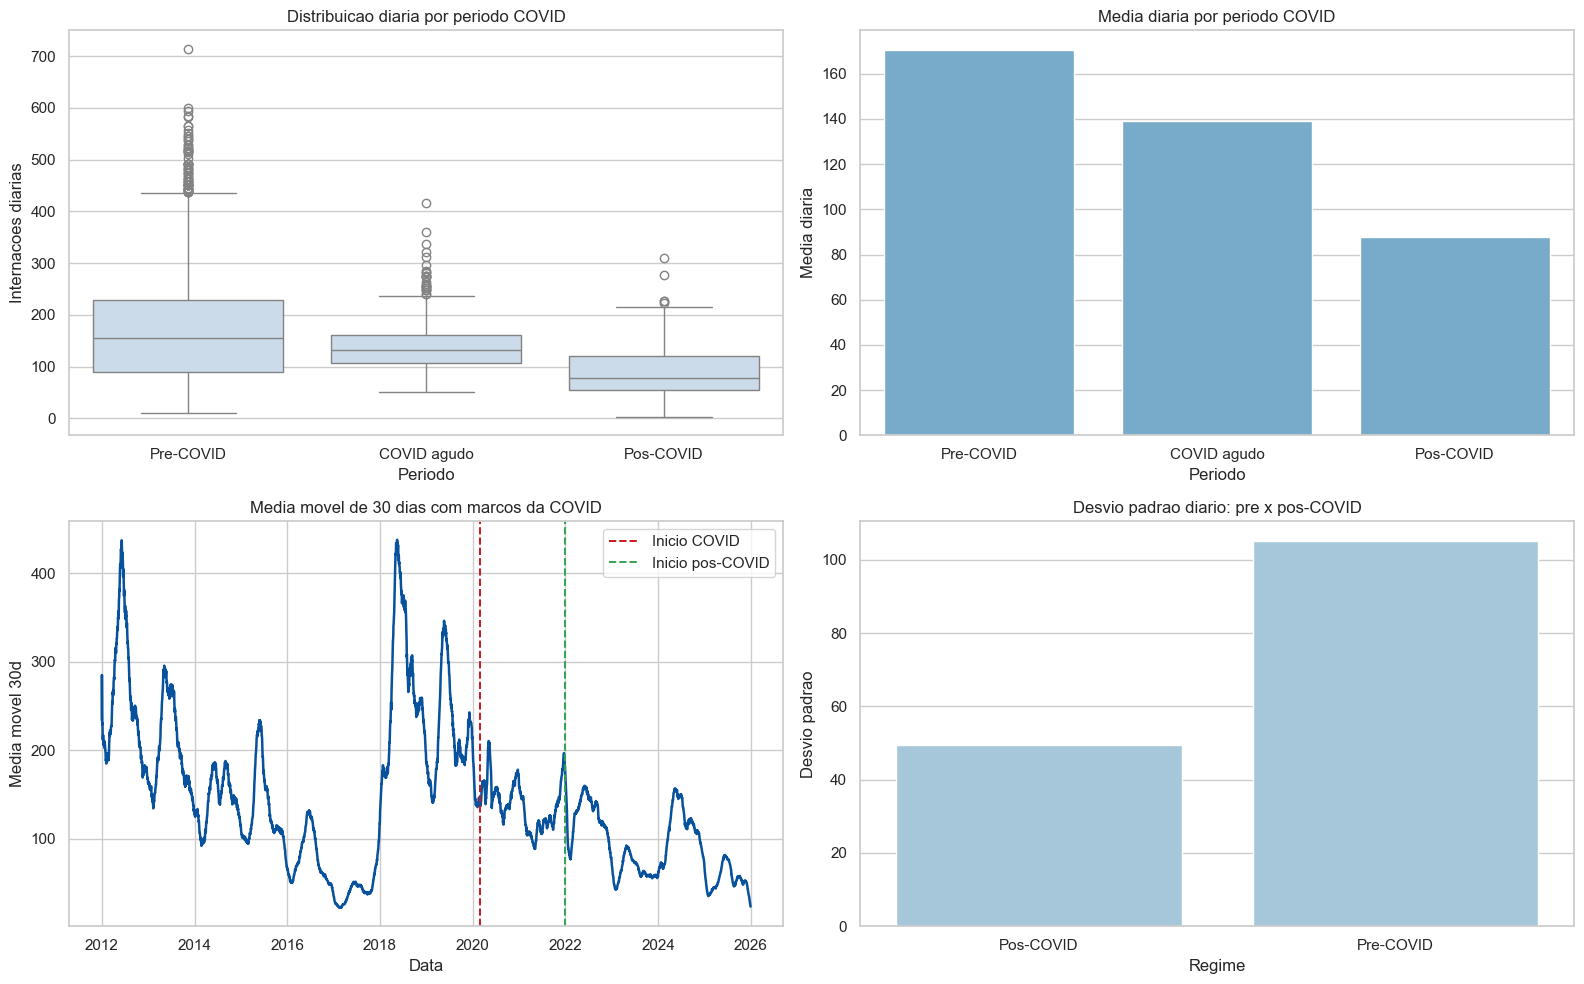

In [ ]:
resumo_periodo_covid = (
    df_eventos.groupby("periodo_covid", observed=True)["num_internacoes"]
    .agg(
        n_dias="count",
        total="sum",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        p95=lambda s: s.quantile(0.95),
    )
    .reset_index()
)

resumo_pre_pos = (
    df_eventos.groupby("pre_pos_covid")["num_internacoes"]
    .agg(n_dias="count", media="mean", mediana="median", desvio_padrao="std", p95=lambda s: s.quantile(0.95))
    .reset_index()
)

display(resumo_periodo_covid.round(2))
display(resumo_pre_pos.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=df_eventos.reset_index(), x="periodo_covid", y="num_internacoes", color="#c6dbef", ax=axes[0, 0])
axes[0, 0].set_title("Distribuicao diaria por periodo COVID")
axes[0, 0].set_xlabel("Periodo")
axes[0, 0].set_ylabel("Internacoes diarias")

sns.barplot(data=resumo_periodo_covid, x="periodo_covid", y="media", color="#6baed6", ax=axes[0, 1])
axes[0, 1].set_title("Media diaria por periodo COVID")
axes[0, 1].set_xlabel("Periodo")
axes[0, 1].set_ylabel("Media diaria")

axes[1, 0].plot(df_eventos.index, df_eventos["media_movel_30d"], color="#08519c", linewidth=1.8)
for data_ref, cor, rotulo in [
    (pd.Timestamp("2020-03-01"), "#cb181d", "Inicio COVID"),
    (pd.Timestamp("2022-01-01"), "#31a354", "Inicio pos-COVID"),
]:
    axes[1, 0].axvline(data_ref, color=cor, linestyle="--", linewidth=1.4, label=rotulo)
axes[1, 0].set_title("Media movel de 30 dias com marcos da COVID")
axes[1, 0].set_xlabel("Data")
axes[1, 0].set_ylabel("Media movel 30d")
axes[1, 0].legend()

sns.barplot(data=resumo_pre_pos, x="pre_pos_covid", y="desvio_padrao", color="#9ecae1", ax=axes[1, 1])
axes[1, 1].set_title("Desvio padrao diario: pre x pos-COVID")
axes[1, 1].set_xlabel("Regime")
axes[1, 1].set_ylabel("Desvio padrao")

plt.tight_layout()
plt.show()

### Ondas epidemicas e mudancas abruptas de nivel/variancia

Para identificar ondas, usamos a media movel de 30 dias e procuramos picos suficientemente separados no tempo. Para detectar mudancas abruptas de nivel e de variabilidade, construimos escores baseados na diferenca entre as janelas atuais e as de 30 dias atras.

,data_pico,media_movel_30d,prominencia
7,2018-05-16,437.60,414.00
1,2012-06-05,437.00,252.00
8,2019-05-21,346.13,205.13
2,2013-05-07,295.50,161.00
0,2012-01-02,285.00,51.00
9,2019-12-06,242.77,59.93
5,2015-05-29,234.00,141.87
10,2020-05-06,210.53,74.70
12,2021-12-20,196.80,108.20
4,2014-09-02,187.93,93.53


,data,score,prominencia
7,2018-04-30,161.80,161.80
10,2019-04-30,116.80,116.67
14,2022-01-22,104.03,104.00
0,2012-06-05,101.00,97.37
8,2018-08-12,98.97,98.77
1,2012-08-12,94.60,91.60
2,2013-04-30,90.83,90.03
4,2015-05-05,88.50,88.40


,data,score,prominencia
15,2020-05-31,61.30,61.30
14,2019-11-30,54.63,54.53
1,2012-07-10,40.29,39.63
17,2022-02-10,39.19,39.17
8,2018-04-12,37.68,37.55
12,2019-04-18,37.42,37.22
3,2013-04-15,36.76,36.67
7,2018-01-10,35.32,34.49


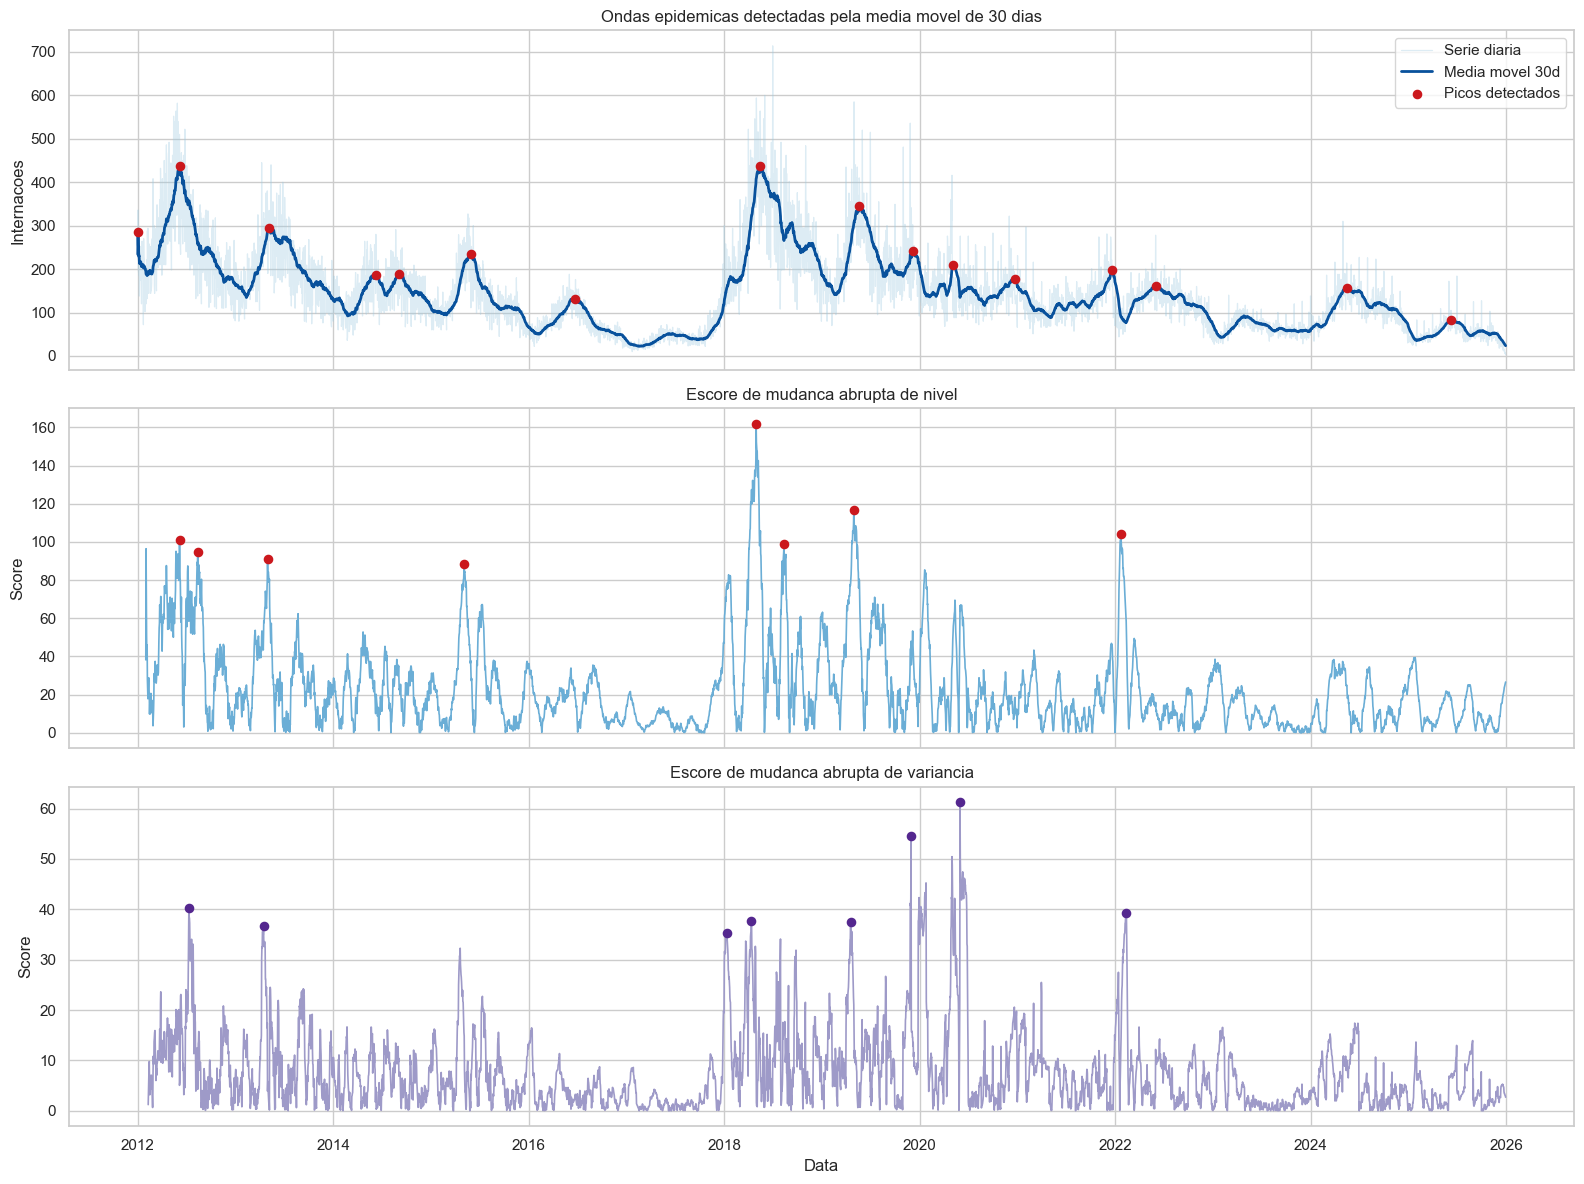

In [ ]:
# Deteccao de ondas a partir da media movel de 30 dias.
serie_ondas = df_eventos["media_movel_30d"].dropna()
prominencia_ondas = max(float(serie_ondas.std() * 0.5), 5.0)
peaks_ondas, props_ondas = find_peaks(serie_ondas.to_numpy(), distance=45, prominence=prominencia_ondas)

ondas_detectadas = pd.DataFrame(
    {
        "data_pico": serie_ondas.index[peaks_ondas],
        "media_movel_30d": serie_ondas.iloc[peaks_ondas].to_numpy(),
        "prominencia": props_ondas.get("prominences", np.array([])),
    }
).sort_values("media_movel_30d", ascending=False)

# Escores diarios de mudanca de nivel e de variancia.
janela_mudanca = 30
df_eventos["score_mudanca_nivel"] = (df_eventos["media_movel_30d"] - df_eventos["media_movel_30d"].shift(janela_mudanca)).abs()
df_eventos["score_mudanca_variancia"] = (df_eventos["desvio_movel_30d"] - df_eventos["desvio_movel_30d"].shift(janela_mudanca)).abs()

candidatos_nivel = detectar_candidatos_por_score(df_eventos["score_mudanca_nivel"], distance=60, quantil_prom=0.92, top_n=8)
candidatos_variancia = detectar_candidatos_por_score(df_eventos["score_mudanca_variancia"], distance=60, quantil_prom=0.92, top_n=8)

display(ondas_detectadas.head(10).round(2))
display(candidatos_nivel.round(2))
display(candidatos_variancia.round(2))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(df_eventos.index, df_eventos["num_internacoes"], color="#9ecae1", alpha=0.35, linewidth=0.9, label="Serie diaria")
axes[0].plot(df_eventos.index, df_eventos["media_movel_30d"], color="#08519c", linewidth=2, label="Media movel 30d")
axes[0].scatter(ondas_detectadas["data_pico"], ondas_detectadas["media_movel_30d"], color="#cb181d", s=35, zorder=3, label="Picos detectados")
axes[0].set_title("Ondas epidemicas detectadas pela media movel de 30 dias")
axes[0].set_ylabel("Internacoes")
axes[0].legend(loc="upper right")

axes[1].plot(df_eventos.index, df_eventos["score_mudanca_nivel"], color="#6baed6", linewidth=1.2)
axes[1].scatter(candidatos_nivel["data"], candidatos_nivel["score"], color="#cb181d", s=35, zorder=3)
axes[1].set_title("Escore de mudanca abrupta de nivel")
axes[1].set_ylabel("Score")

axes[2].plot(df_eventos.index, df_eventos["score_mudanca_variancia"], color="#9e9ac8", linewidth=1.2)
axes[2].scatter(candidatos_variancia["data"], candidatos_variancia["score"], color="#54278f", s=35, zorder=3)
axes[2].set_title("Escore de mudanca abrupta de variancia")
axes[2].set_xlabel("Data")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

### Changepoints em escala mensal

Para reduzir ruido diario e detectar melhor mudancas estruturais, agregamos a serie por mes. Depois aplicamos duas abordagens:
- **Pettitt**, para encontrar um ponto principal de ruptura;
- um **escore combinado** de mudanca de nivel e variabilidade mensal, para levantar varios changepoints candidatos.

,data_changepoint,estatistica_k,p_valor_aprox,n_observacoes
0,2021-01-01,3435.0,0.0,168


,data_changepoint,score,prominencia,media_mensal,desvio_mensal,score_changepoint
8,2022-01-01,5.890,5.826,83.806,20.658,5.890
3,2018-04-01,5.867,5.616,407.600,73.314,5.867
6,2019-11-01,5.324,4.610,231.200,90.878,5.324
5,2019-04-01,5.114,4.150,303.633,57.564,5.114
7,2020-04-01,4.663,3.892,195.333,80.303,4.663
0,2012-05-01,4.211,3.598,421.935,104.939,4.211
4,2018-07-01,4.196,3.345,318.516,112.734,4.196
2,2015-04-01,4.022,3.947,198.300,43.283,4.022


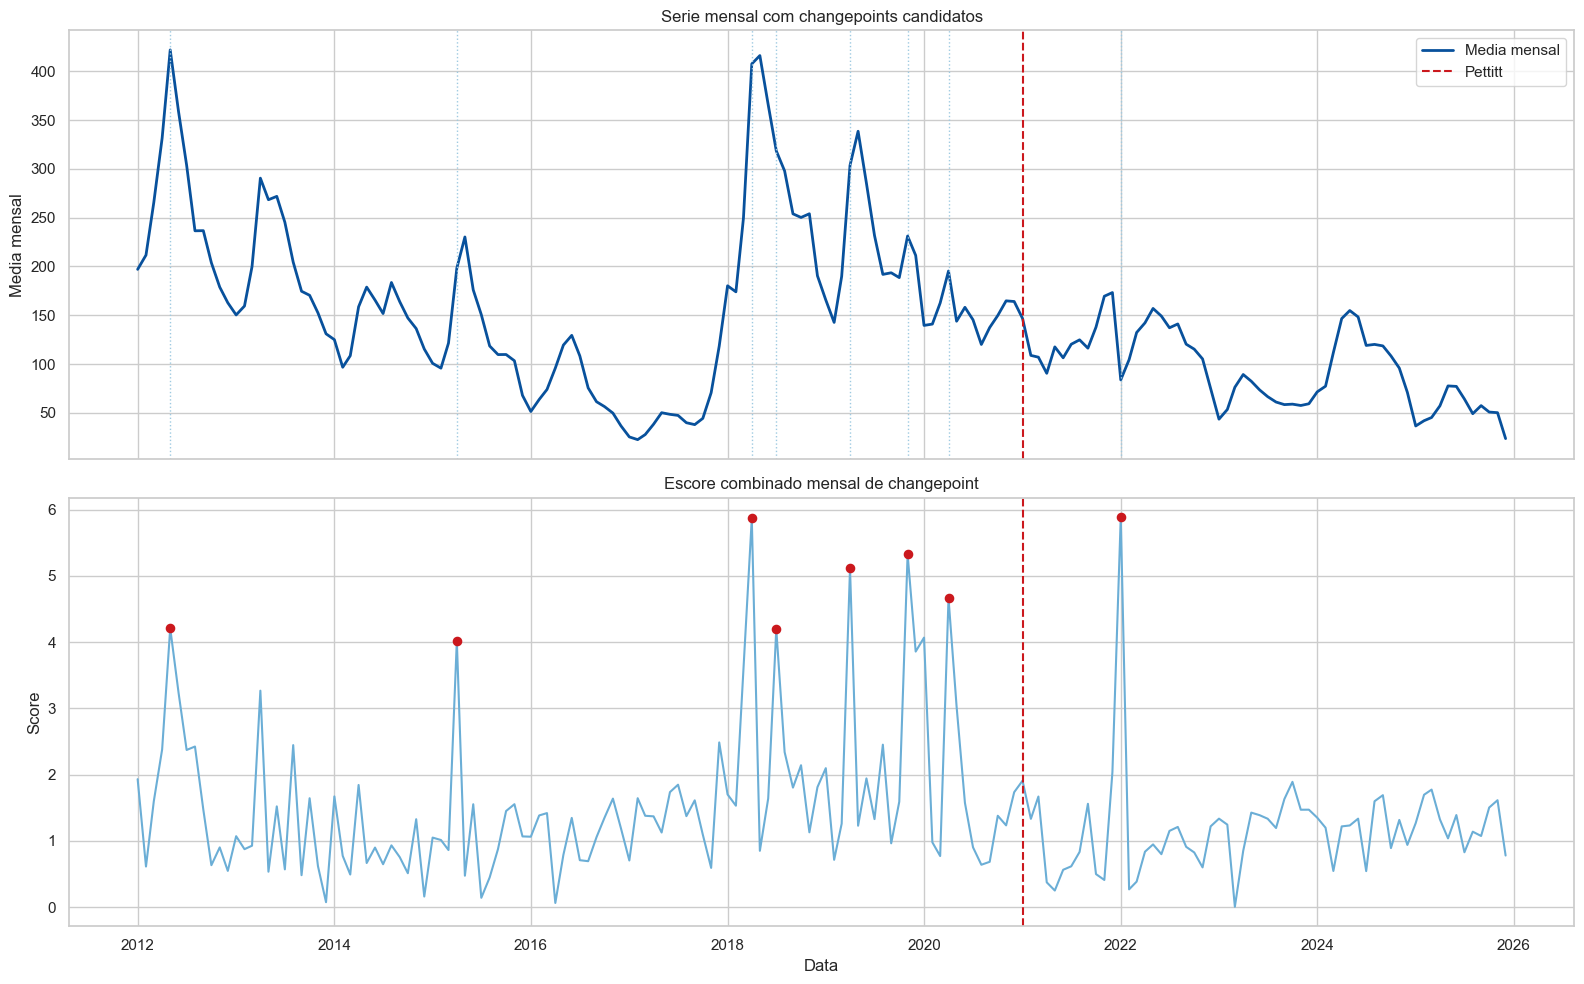

In [ ]:
mensal_eventos = (
    df_eventos["num_internacoes"]
    .resample("MS")
    .agg(["mean", "median", "std", "sum"])
    .rename(columns={"mean": "media_mensal", "median": "mediana_mensal", "std": "desvio_mensal", "sum": "total_mensal"})
)

mensal_eventos["delta_media_abs"] = mensal_eventos["media_mensal"].diff().abs()
mensal_eventos["delta_desvio_abs"] = mensal_eventos["desvio_mensal"].diff().abs()
mensal_eventos["score_changepoint"] = normalizar_z(mensal_eventos["delta_media_abs"].fillna(0)).abs() + normalizar_z(mensal_eventos["delta_desvio_abs"].fillna(0)).abs()

resultado_pettitt = pettitt_test(mensal_eventos["media_mensal"])

candidatos_changepoint = detectar_candidatos_por_score(
    mensal_eventos["score_changepoint"],
    distance=2,
    quantil_prom=0.85,
    top_n=8,
).rename(columns={"data": "data_changepoint"})

candidatos_changepoint = candidatos_changepoint.merge(
    mensal_eventos[["media_mensal", "desvio_mensal", "score_changepoint"]],
    left_on="data_changepoint",
    right_index=True,
    how="left",
)

display(pd.DataFrame([resultado_pettitt]).round(4))
display(candidatos_changepoint.round(3))

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(mensal_eventos.index, mensal_eventos["media_mensal"], color="#08519c", linewidth=2, label="Media mensal")
axes[0].axvline(resultado_pettitt["data_changepoint"], color="#cb181d", linestyle="--", linewidth=1.5, label="Pettitt")
for data_cp in candidatos_changepoint["data_changepoint"]:
    axes[0].axvline(data_cp, color="#9ecae1", linestyle=":", linewidth=1)
axes[0].set_title("Serie mensal com changepoints candidatos")
axes[0].set_ylabel("Media mensal")
axes[0].legend(loc="upper right")

axes[1].plot(mensal_eventos.index, mensal_eventos["score_changepoint"], color="#6baed6", linewidth=1.5)
axes[1].scatter(candidatos_changepoint["data_changepoint"], candidatos_changepoint["score"], color="#cb181d", s=35, zorder=3)
axes[1].axvline(resultado_pettitt["data_changepoint"], color="#cb181d", linestyle="--", linewidth=1.5)
axes[1].set_title("Escore combinado mensal de changepoint")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

### Resumo interpretativo dos resultados

Os resultados reforcam que a serie **nao e estacionaria ao longo de todo o periodo** e que ela passou por **mudancas de regime relevantes**. A comparacao entre os grandes blocos temporais mostrou um nivel medio claramente mais alto no **pre-COVID** do que no **COVID agudo** e, principalmente, no **pos-COVID**. Na comparacao binaria pre x pos-COVID, a media diaria caiu de aproximadamente **170,1** para **104,1**, uma reducao de cerca de **38,8%**. A dispersao tambem caiu bastante, com reducao de cerca de **53,1%** no desvio padrao e de aproximadamente **49,5%** no percentil 95. Isso sugere que, alem de o nivel medio da serie ter diminuido, ela tambem ficou menos volatil nos anos mais recentes.

A deteccao de ondas pela media movel de 30 dias mostrou picos muito expressivos em **2018-05-16 (437,6)** e **2012-06-05 (437,0)**, seguidos por uma nova onda forte em **2019-05-21 (346,1)**. Esses resultados sao coerentes com o que ja aparecia nas etapas anteriores: a serie concentra seus maiores movimentos em janelas especificas e nao de forma uniforme ao longo do tempo. Em termos praticos, isso indica que eventos ou surtos locais/temporais tiveram papel importante na configuracao da serie.

Os escores de mudanca abrupta de nivel apontaram datas muito concentradas em **2018**, **2019** e **inicio de 2022**, com destaque para **2018-04-30**, **2019-04-30** e **2022-01-22**. Isso sugere transicoes rapidas entre patamares de internacao. Ja os escores de mudanca de variancia destacaram principalmente **2020-05-31**, **2019-11-30** e **2022-02-10**, mostrando que a serie nao mudou apenas de nivel: em certos momentos ela tambem mudou de estabilidade, ficando mais ou menos dispersa.

A analise mensal consolidou esse diagnostico. O teste de **Pettitt** identificou um changepoint principal em **2021-01-01**, com p-valor aproximado praticamente nulo, o que fornece evidencia forte de ruptura estrutural. Alem disso, os changepoints candidatos mais relevantes ficaram em meses como **2018-04**, **2019-04**, **2019-11**, **2020-04** e **2022-01**. Em conjunto, esses pontos sugerem que a serie passou por varios momentos de reorganizacao, e nao por uma unica mudanca isolada.

Outro aspecto importante e que os anos com grandes ondas tambem aparecem entre os mais instaveis. O bloco de **2018-2019** se destaca tanto nos picos epidemiologicos quanto nas mudancas abruptas de nivel, enquanto **2020-2022** aparece com forte sinal de mudanca de variancia e com a ruptura principal apontada em torno de **2021**. Isso sugere que a dinamica da serie mudou de forma multifacetada: houve anos com picos muito intensos e outros com reconfiguracao de patamar e de volatilidade.

**Possiveis analises e consequencias**
- A modelagem nao deve assumir um unico regime temporal para toda a serie sem ao menos testar segmentacoes ou variaveis de mudanca de regime.
- O marco em torno de **2021** deve ser considerado explicitamente, seja como dummy, seja como ponto de corte para avaliacao separada de periodos.
- Os anos **2018** e **2019** merecem investigacao mais detalhada, porque concentram ondas fortes e mudancas abruptas de nivel.
- O fato de o pos-COVID ser menos intenso e menos volatil sugere que modelos treinados em todo o historico podem superestimar a demanda recente se nao controlarem regime e tendencia.
- As ondas e changepoints detectados podem ser usados para guiar uma analise posterior com variaveis externas, como poluicao, clima, surtos e mudancas operacionais do sistema de saude.